In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

# set random seed for consistency
torch.manual_seed(42)
np.random.seed(42)


In [63]:
WINDOW_SIZE = 8
PREDICTION_HORIZON = 2
HIDDEN_SIZE = 14

print(f"Window Size: {WINDOW_SIZE}, Horizon: {PREDICTION_HORIZON}, Hidden: {HIDDEN_SIZE}")


Window Size: 8, Horizon: 2, Hidden: 14


In [64]:
file_path = '/kaggle/input/datasets/sumanthvrao/daily-climate-time-series-data/DailyDelhiClimateTrain.csv'

df = pd.read_csv(file_path, parse_dates=['date'], index_col='date')

if 'meantemp' in df.columns:
    data_values = df['meantemp'].values.reshape(-1,1)
else:
    data_values = df.iloc[:,0].values.reshape(-1,1)

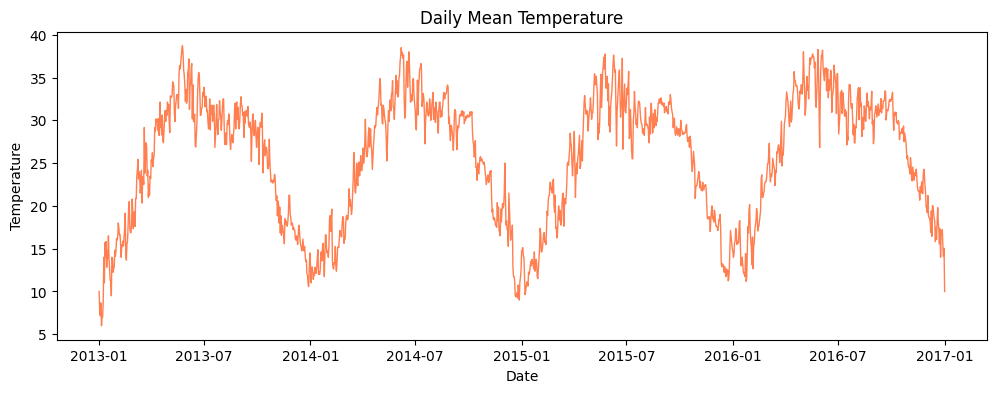

In [65]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, data_values, color='coral', linewidth=1)
plt.title('Daily Mean Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.show()

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_values)

In [66]:
def create_sequences(data, window_size, horizon):
    xs, ys = [], []
    for i in range(len(data) - window_size - horizon + 1):
        x = data[i:(i + window_size)]
        y = data[(i + window_size):(i + window_size + horizon)]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

X, y = create_sequences(scaled_data, WINDOW_SIZE, PREDICTION_HORIZON)

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [67]:
class CustomRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CustomRNN, self).__init__()
        self.hidden_size = hidden_size
        self.W_ih = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.W_hh = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.b_h = nn.Parameter(torch.Tensor(hidden_size))
        self.W_ho = nn.Parameter(torch.Tensor(hidden_size, output_size))
        self.b_o = nn.Parameter(torch.Tensor(output_size))
        self.init_weights()
        
    def init_weights(self):
        stdv = 1.0 / math.sqrt(self.hidden_size)
        for weight in self.parameters():
            weight.data.uniform_(-stdv, stdv)

    def forward(self, x):
        batch_size = x.size(0)
        seq_len = x.size(1)
        h_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
        for t in range(seq_len):
            x_t = x[:, t, :]
            h_t = torch.tanh(torch.matmul(x_t, self.W_ih) + torch.matmul(h_t, self.W_hh) + self.b_h)
        output = torch.matmul(h_t, self.W_ho) + self.b_o
        return output

In [68]:
class MLPBaseline(nn.Module):
    def __init__(self, input_size, window_size, hidden_size, output_size):
        super(MLPBaseline, self).__init__()
        self.fc1 = nn.Linear(input_size * window_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [69]:
class PrebuiltLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PrebuiltLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

class SimpleTransformer(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_heads=2):
        super(SimpleTransformer, self).__init__()
        self.input_proj = nn.Linear(input_size, hidden_size)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_size, nhead=num_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.input_proj(x)
        out = self.transformer(x)
        out = out.mean(dim=1)
        out = self.fc(out)
        return out

In [70]:
def train_model(model, X_tr, y_tr, epochs=150, lr=0.01):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X_tr)
        loss = criterion(outputs, y_tr.squeeze(-1))
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

def evaluate_model(model, X_te, y_te, scaler, name="Model"):
    model.eval()
    with torch.no_grad():
        preds = model(X_te)
    
    # evaluating the entire prediction horizon (all 2 steps)
    preds_inv = scaler.inverse_transform(preds.numpy().reshape(-1, 1))
    y_te_inv = scaler.inverse_transform(y_te.squeeze(-1).numpy().reshape(-1, 1))
    
    mse = mean_squared_error(y_te_inv, preds_inv)
    mae = mean_absolute_error(y_te_inv, preds_inv)
    rmse = math.sqrt(mse)
    print(f"{name} -> MSE: {mse:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}")
    return preds_inv.reshape(preds.shape), y_te_inv.reshape(y_te.squeeze(-1).shape)


In [71]:
print("training custom rnn...")
rnn_model = CustomRNN(1, HIDDEN_SIZE, PREDICTION_HORIZON)
rnn_losses = train_model(rnn_model, X_train, y_train, epochs=200, lr=0.005)
rnn_p, rnn_y = evaluate_model(rnn_model, X_test, y_test, scaler, "Custom RNN")

print("training mlp baseline...")
mlp_model = MLPBaseline(1, WINDOW_SIZE, HIDDEN_SIZE, PREDICTION_HORIZON)
mlp_losses = train_model(mlp_model, X_train, y_train, epochs=200, lr=0.005)
mlp_p, mlp_y = evaluate_model(mlp_model, X_test, y_test, scaler, "MLP")

print("training prebuilt lstm...")
lstm_model = PrebuiltLSTM(1, HIDDEN_SIZE, PREDICTION_HORIZON)
lstm_losses = train_model(lstm_model, X_train, y_train, epochs=200, lr=0.005)
lstm_p, lstm_y = evaluate_model(lstm_model, X_test, y_test, scaler, "LSTM")

print("training transformer...")
tf_model = SimpleTransformer(1, HIDDEN_SIZE, PREDICTION_HORIZON)
tf_losses = train_model(tf_model, X_train, y_train, epochs=200, lr=0.005)
tf_p, tf_y = evaluate_model(tf_model, X_test, y_test, scaler, "Transformer")


training custom rnn...
Custom RNN -> MSE: 3.8153, MAE: 1.5338, RMSE: 1.9533
training mlp baseline...
MLP -> MSE: 4.7531, MAE: 1.7208, RMSE: 2.1802
training prebuilt lstm...
LSTM -> MSE: 3.8892, MAE: 1.5428, RMSE: 1.9721
training transformer...
Transformer -> MSE: 5.1129, MAE: 1.8079, RMSE: 2.2612


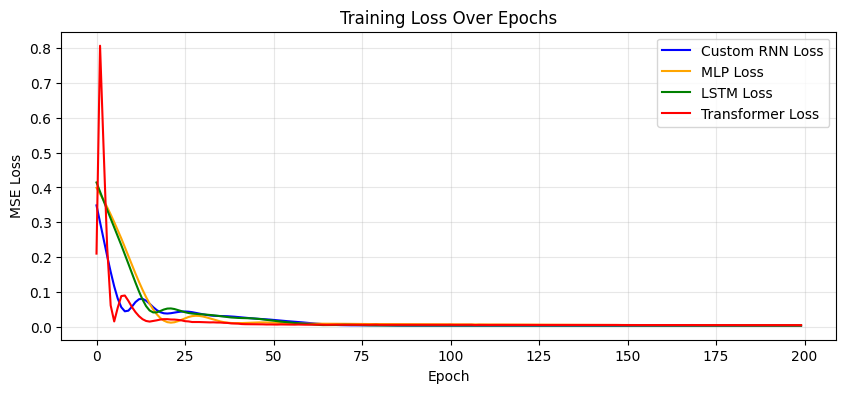

In [72]:
plt.figure(figsize=(10, 4))
plt.plot(rnn_losses, label='Custom RNN Loss', color='blue')
plt.plot(mlp_losses, label='MLP Loss', color='orange')
plt.plot(lstm_losses, label='LSTM Loss', color='green')
plt.plot(tf_losses, label='Transformer Loss', color='red')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

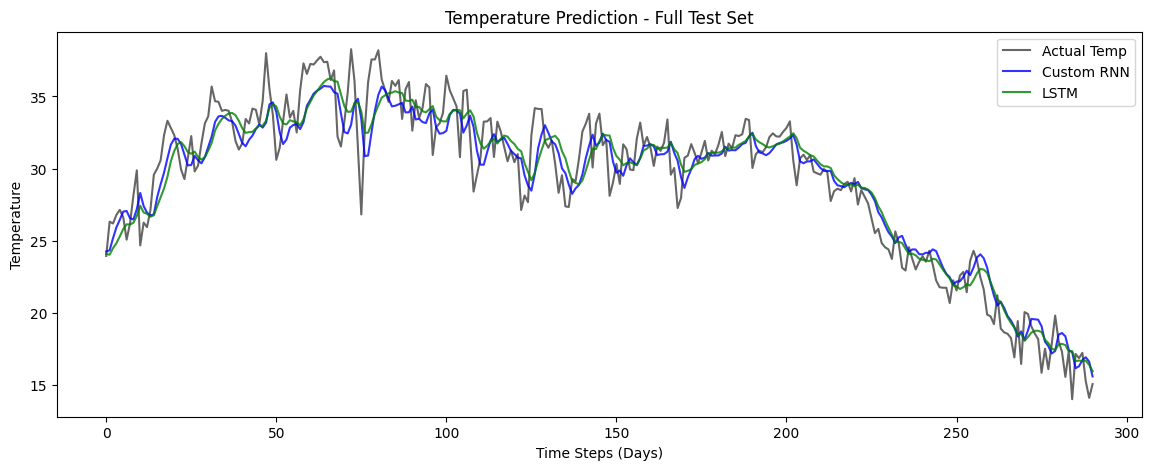

In [73]:
plt.figure(figsize=(14, 5))
plt.plot(rnn_y[:, 0], label='Actual Temp', color='black', alpha=0.6)
plt.plot(rnn_p[:, 0], label='Custom RNN', color='blue', alpha=0.8)
plt.plot(lstm_p[:, 0], label='LSTM', color='green', alpha=0.8)
plt.title('Temperature Prediction - Full Test Set')
plt.xlabel('Time Steps (Days)')
plt.ylabel('Temperature')
plt.legend()
plt.show()

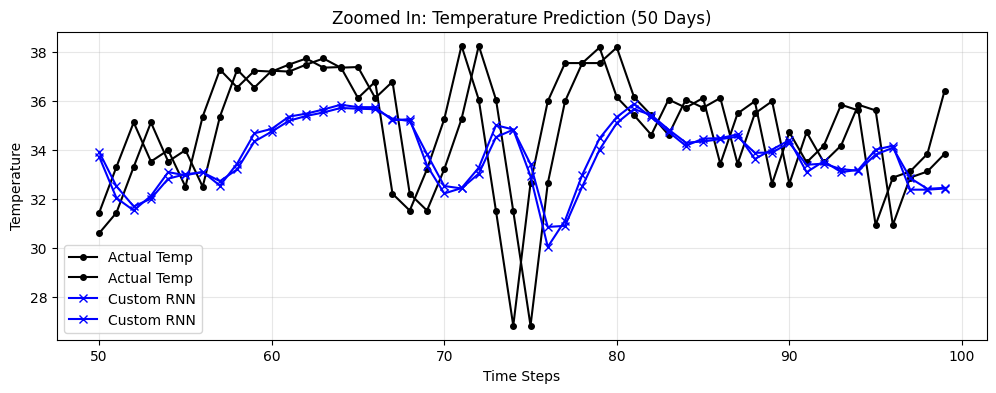

In [74]:
start_idx = 50
end_idx = 100
plt.figure(figsize=(12, 4))
plt.plot(range(start_idx, end_idx), rnn_y[start_idx:end_idx], label='Actual Temp', color='black', marker='o', markersize=4)
plt.plot(range(start_idx, end_idx), rnn_p[start_idx:end_idx], label='Custom RNN', color='blue', marker='x')
plt.title('Zoomed In: Temperature Prediction (50 Days)')
plt.xlabel('Time Steps')
plt.ylabel('Temperature')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

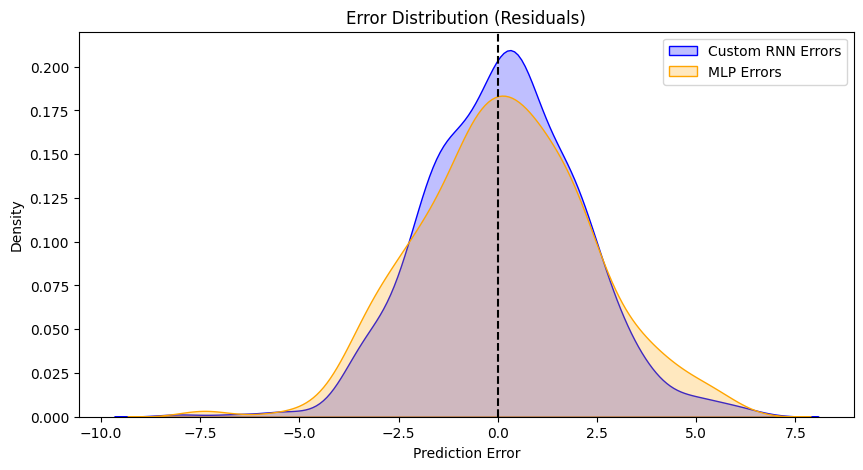

In [75]:
rnn_errors = rnn_y - rnn_p
mlp_errors = mlp_y - mlp_p

plt.figure(figsize=(10, 5))
sns.kdeplot(rnn_errors.flatten(), fill=True, label='Custom RNN Errors', color='blue')
sns.kdeplot(mlp_errors.flatten(), fill=True, label='MLP Errors', color='orange')
plt.title('Error Distribution (Residuals)')
plt.xlabel('Prediction Error')
plt.ylabel('Density')
plt.legend()
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

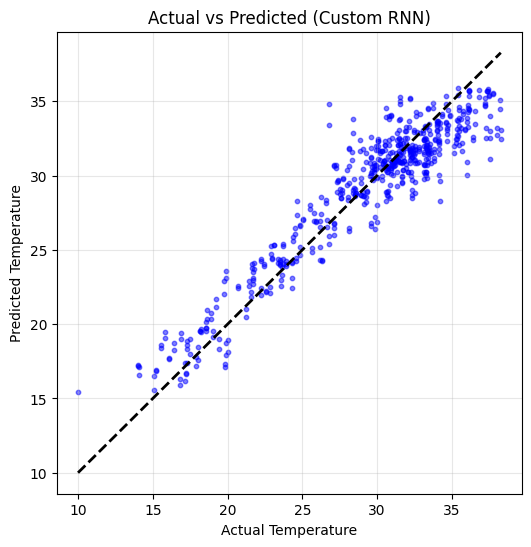

In [76]:
plt.figure(figsize=(6, 6))
plt.scatter(rnn_y, rnn_p, alpha=0.5, color='blue', s=10)
# plot perfect prediction line
min_val = min(rnn_y.min(), rnn_p.min())
max_val = max(rnn_y.max(), rnn_p.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
plt.title('Actual vs Predicted (Custom RNN)')
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.grid(alpha=0.3)
plt.show()

In [77]:
print("\n=== Ablation Study: Window Sizes ===")
ablation_windows = [WINDOW_SIZE // 2, WINDOW_SIZE, WINDOW_SIZE * 2] # 4, 8, 16

for w in ablation_windows:
    if w <= 0: continue
    print(f"\ntesting window size: {w}")
    X_ab, y_ab = create_sequences(scaled_data, w, PREDICTION_HORIZON)
    train_sz = int(len(X_ab) * 0.8)
    
    X_ab_tr = torch.tensor(X_ab[:train_sz], dtype=torch.float32)
    y_ab_tr = torch.tensor(y_ab[:train_sz], dtype=torch.float32)
    X_ab_te = torch.tensor(X_ab[train_sz:], dtype=torch.float32)
    y_ab_te = torch.tensor(y_ab[train_sz:], dtype=torch.float32)
    
    ab_model = CustomRNN(input_size=1, hidden_size=HIDDEN_SIZE, output_size=PREDICTION_HORIZON)
    train_model(ab_model, X_ab_tr, y_ab_tr, epochs=150, lr=0.005)
    evaluate_model(ab_model, X_ab_te, y_ab_te, scaler, f"Custom RNN (Window={w})")


=== Ablation Study: Window Sizes ===

testing window size: 4
Custom RNN (Window=4) -> MSE: 4.0930, MAE: 1.5769, RMSE: 2.0231

testing window size: 8
Custom RNN (Window=8) -> MSE: 4.1130, MAE: 1.5913, RMSE: 2.0280

testing window size: 16
Custom RNN (Window=16) -> MSE: 3.7708, MAE: 1.5149, RMSE: 1.9419
